# 語意護欄

In [ ]:
! pip install langchain_huggingface
! pip install --upgrade transformers

# 載入模型並測試

In [ ]:
# 載入模型

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline

model_id = "google/gemma-4-E2B-it" # 您可以替換成上述推薦的其他模型ID

print(f"正在載入模型：{model_id}")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1000,
    do_sample=False,
)

llm = HuggingFacePipeline(pipeline=pipe)
chat_model = ChatHuggingFace(llm=llm)

正在載入模型：google/gemma-4-E2B-it


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
# 測試模型
from langchain_core.messages import HumanMessage, SystemMessage
for chunk in chat_model.stream([HumanMessage(content="簡短的說明機器學習的原理")]):
  print(chunk.content, end="", flush=True)
print("\n")

Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## 機器學習的原理：簡短說明

**機器學習 (Machine Learning, ML)** 的核心思想是**讓電腦系統能夠從數據中「學習」規律和模式，並根據這些學習到的知識來做出預測或決策，而無需被明確地編寫每一步的規則。**

你可以將機器學習想像成教一個小孩識別貓和狗的過程：

### 核心步驟與概念：

1. **數據 (Data)：** 這是機器學習的「食物」。你需要大量的、有代表性的數據（例如，成千上萬張標註了「貓」和「狗」的照片）。
2. **模型 (Model)：** 這是學習的「知識體」。模型是透過分析數據，從中提取出數學關係和模式的結構。
3. **訓練 (Training)：** 這是學習的過程。我們將數據餵給演算法（例如神經網路），讓它不斷調整自己的內部參數，直到它能準確地將輸入（圖片）與正確的輸出（貓/狗）聯繫起來。
4. **預測 (Prediction)：** 一旦模型訓練完成，我們就可以給它全新的、未見過的數據，讓它根據學到的模式來做出預測（例如，給它一張新照片，它就能判斷出這是貓）。

### 簡單總結：

**機器學習的目標是：** 讓演算法**自動地**從**數據**中**學習**出**規律**，從而建立一個**模型**，以便在**沒有明確編程**的情況下，對**新數據**做出**準確的預測或決策**。

---

### 兩種主要的學習類型：

* **監督式學習 (Supervised Learning)：** 數據中包含**答案（標籤）**。模型學習的是「輸入 $\rightarrow$ 輸出」的對應關係（例如：給它貓的照片，告訴它「這是貓」）。
* **非監督式學習 (Unsupervised Learning)：** 數據中**沒有答案**。模型需要自己去發現數據中隱藏的結構、群組或模式（例如：讓它自己把相似的客戶分到同一個群組）。



# 使用LLM來進行語意護欄

## 模擬電子商務客服

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
system_prompt = '''
你是一位電子商務的客服人員，專門處理客戶查詢、訂單問題和產品資訊。請用友善且專業的語氣回答問題。
'''
user_prompt = "請問在你們網站購物，一定需要註冊會員嗎？"

message = [
  SystemMessage(system_prompt),
  HumanMessage(content=user_prompt)
]

for chunk in chat_model.stream(message):
  print(chunk.content, end="", flush=True)
print("\n")


Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


您好！感謝您對我們網站的關注與詢問。😊

關於您想知道是否一定需要註冊會員來購物，我想為您說明一下：

**不一定需要！**

我們的網站提供兩種購物方式供您選擇：

1. **未註冊/訪客模式 (Guest Checkout)：** 您可以直接使用您的帳號（例如電子郵件或電話）完成訂單，無需事先註冊會員。這對於想快速購買或只是偶爾購物的朋友非常方便。
2. **註冊會員：** 註冊會員有許多優點，例如可以儲存地址、追蹤訂單歷史、享有會員專屬折扣或獨家優惠等。

**總結來說：** 您可以選擇**直接購買**，不需要註冊會員。如果您之後有更頻繁的購物需求，歡迎隨時註冊，這樣可以讓您的購物體驗更加方便和豐富！

請問您還有其他關於購物流程或產品的疑問嗎？我非常樂意為您解答！✨



## 當使用者的問題跟客服無關時

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
system_prompt = '''
你是一位電子商務的客服人員，專門處理客戶查詢、訂單問題和產品資訊。請用友善且專業的語氣回答問題。
'''
user_prompt = "機器學習的原理？"

message = [
  SystemMessage(system_prompt),
  HumanMessage(content=user_prompt)
]

for chunk in chat_model.stream(message):
  print(chunk.content, end="", flush=True)
print("\n")


Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


您好！很高興為您服務。😊

您問到的是**機器學習（Machine Learning, ML）的原理**，這是一個非常廣泛且有趣的主題！作為電子商務的客服人員，我的主要職責是協助您處理**訂單、產品資訊或服務相關**的問題。

不過，我可以為您用一個**簡單易懂的方式**來解釋機器學習的核心原理，讓您有個初步的了解。

---

### 💡 機器學習的核心概念是什麼？

簡單來說，**機器學習就是讓電腦系統能夠「從數據中學習，並在沒有明確編程指令的情況下，自動做出預測或決策」的能力。**

想像一下，傳統的程式是：「如果輸入 A，就輸出 B。」而機器學習是：「給我大量的 A 和 B 的例子，我自己去找出 A 和 B 之間的規律，然後學會如何處理新的 A。」

### 🧠 機器學習的三大核心步驟

機器學習的過程通常可以分解為以下三個主要步驟：

#### 1. 數據 (Data) - 燃料
* **作用：** 數據是機器學習的「燃料」。模型需要大量的、高品質的數據才能學習。
* **舉例：** 如果我們要訓練一個模型來辨識貓和狗的照片，我們就需要成千上萬的「貓的照片」和「狗的照片」。

#### 2. 模型 (Model) - 大腦
* **作用：** 模型就是透過學習數據所建立起來的數學結構或算法。它就是電腦的「大腦」。
* **過程：** 透過輸入數據，模型會不斷調整它內部的參數，直到它能準確地將輸入映射到正確的輸出。

#### 3. 訓練 (Training) - 學習過程
* **作用：** 這是讓模型開始學習的過程。我們將數據餵給模型，讓它不斷地進行「猜測」和「修正」。
* **過程：** 模型會根據預測的錯誤程度來調整自己的內部參數，目標是讓未來預測的準確率越來越高。

#### 4. 預測/推論 (Prediction/Inference) - 應用
* **作用：** 當模型訓練完成後，我們就可以將全新的、未見過的數據輸入給它，讓它根據學到的規律做出預測或決策。
* **舉例：** 輸入一張全新的、模型從未見過的動物照片，模型就能準確地告訴你這張照片是「貓」還是「狗」。

---

### 📊 機器學習的幾種主要類型

機器學習的方法有很多種，最常見的幾種是：

1. **監督式學習 (Supervised Learning)：**
    * *

## 在系統提示詞中加入限制

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
system_prompt = '''
你是一位電子商務的客服人員，專門處理客戶查詢、訂單問題和產品資訊。請用友善且專業的語氣回答問題。
如果使用者的問題跟購物無關，則拒絕回答。
'''
user_prompt = "機器學習的原理？"

message = [
  SystemMessage(system_prompt),
  HumanMessage(content=user_prompt)
]

for chunk in chat_model.stream(message):
  print(chunk.content, end="", flush=True)
print("\n")


Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


您好！非常感謝您的來信。😊

我是一位電子商務的客服人員，主要負責處理**客戶查詢、訂單問題和產品資訊**相關的服務。因此，我不太會提供關於機器學習等技術原理的詳細解釋。

請問您是否有關於我們的**產品、訂單**或是**購物**方面有任何問題呢？我很樂意為您提供協助！✨



# 使用機器學習與嵌入式模型(Embedding Model)來建立語意護欄

## 載入訓練資料與轉換

In [1]:
# 載入訓練資料

import requests
import json

# 原始 GitHub 檔案 URL
file_url = "https://raw.githubusercontent.com/Clement1972/llm-book-example/main/%E8%A3%9C%E5%85%85%E8%B3%87%E6%96%99/data/QA_guardrails.json"

print(f"正在從 {file_url} 讀取內容...")

try:
    response = requests.get(file_url)
    response.raise_for_status() # 檢查請求是否成功 (HTTP 狀態碼 200)

    # 解析 JSON 內容
    qa_data = json.loads(response.text)

    print("成功讀取 JSON 內容 (前五筆)：")
    # 使用 json.dumps 格式化輸出，使其更易讀，並限制為前五筆
    print(json.dumps(qa_data[:5], indent=2, ensure_ascii=False))

except requests.exceptions.RequestException as e:
    print(f"讀取檔案時發生錯誤：{e}")
except json.JSONDecodeError as e:
    print(f"解析 JSON 內容時發生錯誤：{e}")

正在從 https://raw.githubusercontent.com/Clement1972/llm-book-example/main/%E8%A3%9C%E5%85%85%E8%B3%87%E6%96%99/data/QA_guardrails.json 讀取內容...
成功讀取 JSON 內容 (前五筆)：
[
  {
    "text": "我想請問關於忘記密碼怎麼辦呀？",
    "label": "positive"
  },
  {
    "text": "麻煩問一下，你們的東西跟Amazon比，哪裡比較好？",
    "label": "negative"
  },
  {
    "text": "我想請問關於需要準備什麼證明？",
    "label": "positive"
  },
  {
    "text": "請問請問你們是Amazon的子公司嗎？",
    "label": "negative"
  },
  {
    "text": "麻煩問一下，可以講個跟滷肉飯有關的笑話嗎？",
    "label": "negative"
  }
]


In [ ]:
! pip install langchain_huggingface

In [6]:
# 載入嵌入式模型
# 模組匯入
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# 初始化文字嵌入模型，這裡使用 BAAI 提供的中文向量模型 bge-large-zh-v1.5
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-large-zh-v1.5")

# 定義要轉換成向量的文字
text = "床前明月光，疑是地上霜"

# 使用模型將文字轉換為向量（embedding）
query_result = embeddings.embed_query(text)

# 印出向量的長度（維度），用以確認向量大小
print("向量長度:", len(query_result))

# 印出向量的前 3 個數值，快速查看向量內容
print("向量內容:", query_result[:3])

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


向量長度: 1024
向量內容: [0.03762825205922127, -0.008928850293159485, -0.023561280220746994]


In [8]:
# 使用嵌入式模型來編碼

import pandas as pd
from tqdm.auto import tqdm

# 儲存處理後的資料
processed_data = []

# 使用 tqdm 顯示進度條
for item in tqdm(qa_data, desc="處理 Embedding"): # Added tqdm here
    text = item['text']
    label = item['label']

    # 編碼文本
    embedding_vector = embeddings.embed_query(text)

    # 將標籤轉換為數值
    label_numeric = 1 if label == 'positive' else 0

    processed_data.append({
        'text': text,
        'embedding': embedding_vector,
        'label_numeric': label_numeric
    })

# 建立 pandas DataFrame
df = pd.DataFrame(processed_data)

print("DataFrame 已成功建立，前五筆資料如下：")
print(df.head())

處理 Embedding:   0%|          | 0/2000 [00:00<?, ?it/s]

DataFrame 已成功建立，前五筆資料如下：
                         text  \
0             我想請問關於忘記密碼怎麼辦呀？   
1  麻煩問一下，你們的東西跟Amazon比，哪裡比較好？   
2             我想請問關於需要準備什麼證明？   
3         請問請問你們是Amazon的子公司嗎？   
4       麻煩問一下，可以講個跟滷肉飯有關的笑話嗎？   

                                           embedding  label_numeric  
0  [-0.04360455647110939, 0.00603876169770956, 0....              1  
1  [-0.035753652453422546, 0.009125150740146637, ...              0  
2  [-0.010860994458198547, -0.01774795725941658, ...              1  
3  [-0.06097233667969704, 0.02474662847816944, -0...              0  
4  [-0.026677433401346207, 0.025400256738066673, ...              0  


### 將 Embedding 向量展開為多個獨立欄位

由於目前 `embedding` 欄位儲存的是一個包含 1024 個數字的列表，如果您希望將這些數字單獨作為 DataFrame 的欄位，可以使用以下程式碼將其展開。這對於某些機器學習模型的輸入格式可能很有用。

In [9]:
# 將 embedding 欄位展開成多個欄位
embedding_df = pd.DataFrame(df['embedding'].to_list(), index=df.index)
embedding_df.columns = [f'embedding_{i}' for i in range(embedding_df.shape[1])]

# 將原始 DataFrame 的 text 和 label_numeric 欄位與展開後的 embedding 欄位合併
df_expanded = pd.concat([df[['text', 'label_numeric']], embedding_df], axis=1)

print("展開 embedding 欄位後的 DataFrame 前五筆資料如下：")
display(df_expanded.head())

print(f"新的 DataFrame 包含 {df_expanded.shape[1]} 個欄位，其中 {embedding_df.shape[1]} 個為 embedding 相關欄位。")

展開 embedding 欄位後的 DataFrame 前五筆資料如下：


,text,label_numeric,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_1014,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023
0,我想請問關於忘記密碼怎麼辦呀？,1,-0.043605,0.006039,0.046835,0.029018,0.015644,0.027465,-0.011098,0.015428,...,-0.005282,-0.012302,-0.030569,0.022154,-0.080187,0.005751,-0.018507,0.011158,-0.027503,-0.009155
1,麻煩問一下，你們的東西跟Amazon比，哪裡比較好？,0,-0.035754,0.009125,-0.021831,-0.046714,0.016375,0.005585,-0.029723,-0.010134,...,-0.011768,0.024556,-0.045381,-0.004944,0.008248,0.034471,-0.005458,-0.034283,0.007912,0.015470
2,我想請問關於需要準備什麼證明？,1,-0.010861,-0.017748,0.025171,0.007045,-0.007439,-0.014862,0.007722,0.061549,...,-0.031686,0.024910,-0.003368,0.024591,-0.036688,-0.021095,0.039589,-0.004830,0.004963,-0.017886
3,請問請問你們是Amazon的子公司嗎？,0,-0.060972,0.024747,-0.050154,-0.011029,-0.013279,-0.007011,-0.067124,0.020251,...,0.014944,-0.010560,-0.022477,0.002845,0.003640,0.007241,-0.055248,-0.003129,0.048917,0.024584
4,麻煩問一下，可以講個跟滷肉飯有關的笑話嗎？,0,-0.026677,0.025400,-0.041728,0.007421,0.044260,-0.021620,0.029391,0.021850,...,0.008489,0.030687,-0.011210,0.039418,-0.033163,0.020043,0.014295,-0.008274,-0.069790,0.007096


新的 DataFrame 包含 1026 個欄位，其中 1024 個為 embedding 相關欄位。


## 將資料的分布使用PCA進行可視化轉換

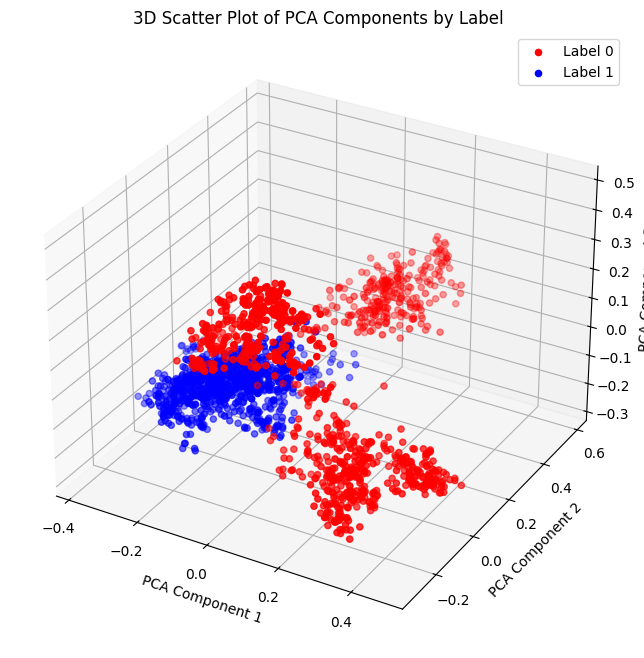

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 提取 embedding 相關的欄位
X = df_expanded.filter(like='embedding_').values
y = df_expanded['label_numeric'].values

# 執行 PCA 降維到 3 個主成分
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# 將 PCA 結果添加到 DataFrame 中，以便後續繪圖
df_pca = pd.DataFrame(data=X_pca, columns=['pca_component_1', 'pca_component_2', 'pca_component_3'])
df_pca['label_numeric'] = y

# 繪製 3D 散佈圖
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 為每個類別設定顏色
colors = ['red', 'blue'] # 0 for negative, 1 for positive

for i, label in enumerate(np.unique(y)):
    # 選擇對應的數據點
    idx = df_pca['label_numeric'] == label
    ax.scatter(df_pca.loc[idx, 'pca_component_1'],
               df_pca.loc[idx, 'pca_component_2'],
               df_pca.loc[idx, 'pca_component_3'],
               c=colors[i],
               label=f'Label {label}',
               s=20)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Scatter Plot of PCA Components by Label')
ax.legend()
ax.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 提取特徵 (X) 和目標變數 (y)
X = df_expanded.filter(like='embedding_') # 選擇所有 embedding 相關的欄位作為特徵
y = df_expanded['label_numeric'] # label_numeric 作為目標變數

# 將資料分成訓練集和測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"訓練集大小: {len(X_train)} 筆資料")
print(f"測試集大小: {len(X_test)} 筆資料")
print("\n正在訓練隨機森林模型...")

# 初始化隨機森林分類器
# 可以調整 n_estimators (樹的數量), max_depth (樹的最大深度) 等參數來優化模型
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 使用所有核心加速訓練

# 訓練模型
rf_classifier.fit(X_train, y_train)

print("模型訓練完成。\n")

# 在測試集上進行預測
y_pred = rf_classifier.predict(X_test)

# 評估模型性能
accuracy = accuracy_score(y_test, y_pred)
print(f"模型準確率 (Accuracy): {accuracy:.4f}\n")

print("分類報告 (Classification Report):\n")
print(classification_report(y_test, y_pred))

訓練集大小: 1600 筆資料
測試集大小: 400 筆資料

正在訓練隨機森林模型...
模型訓練完成。

模型準確率 (Accuracy): 0.9975

分類報告 (Classification Report):

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 建立語意護欄預測函數

這個函數將接收一個問題字串，執行以下步驟：
1.  使用相同的 `HuggingFaceEmbeddings` 模型將問題字串轉換為向量。
2.  將這個向量轉換為 `DataFrame` 格式，以符合訓練時的 `X` 特徵格式。
3.  使用訓練好的 `rf_classifier` 進行預測。
4.  將預測結果（0 或 1）轉換回 'negative' 或 'positive' 的文字標籤。

In [13]:
def predict_guardrail_label(query_string: str):
    """
    預測問題字串是否為客服相關 (positive) 或無關 (negative)。
    """
    # 1. 將查詢字串編碼成向量
    query_embedding = embeddings.embed_query(query_string)

    # 2. 將向量轉換為 DataFrame 格式，以符合模型輸入
    # 模型的輸入需要是 2D 陣列，且欄位名稱需要對應
    query_embedding_df = pd.DataFrame([query_embedding])
    query_embedding_df.columns = [f'embedding_{i}' for i in range(len(query_embedding))]

    # 3. 使用訓練好的模型進行預測
    prediction = rf_classifier.predict(query_embedding_df)

    # 4. 將預測結果轉換為文字標籤
    predicted_label = 'positive' if prediction[0] == 1 else 'negative'

    print(f"問題: \"{query_string}\"")
    print(f"預測結果: {predicted_label}")
    return predicted_label

print("預測函數已建立。")

預測函數已建立。


## 測試語意護欄預測函數

In [20]:
%%time
# 測試正向案例 (客服相關)
predict_guardrail_label("請問我的訂單狀態是什麼？")
predict_guardrail_label("如何修改我的收貨地址？")
predict_guardrail_label("這個商品的退換貨政策是什麼？")
predict_guardrail_label("我如何申請退貨？")
predict_guardrail_label("你們的客服電話是多少？")
predict_guardrail_label("我收到的商品有瑕疵怎麼辦？")
predict_guardrail_label("我想查詢發票資訊。")
predict_guardrail_label("請問有貨到付款的選項嗎？")
predict_guardrail_label("我的會員點數還剩下多少？")
predict_guardrail_label("訂單多久會出貨？")

print("\n------\n")

# 測試負向案例 (與客服無關)
predict_guardrail_label("你覺得今天的晚餐要吃什麼？")
predict_guardrail_label("台灣的氣候怎麼樣？")
predict_guardrail_label("可以告訴我關於量子物理學的知識嗎？")
predict_guardrail_label("跟我說說如何使用機器學習吧！")
predict_guardrail_label("推薦一些旅遊景點吧！")
predict_guardrail_label("最近有什麼好看的電影嗎？")
predict_guardrail_label("可以解釋一下人工智慧的原理嗎？")
predict_guardrail_label("世界最高峰是哪一座山？")
predict_guardrail_label("數學中最美的公式是什麼？")
predict_guardrail_label("幫我寫一個關於太空旅行的短故事。")

問題: "請問我的訂單狀態是什麼？"
預測結果: positive
問題: "如何修改我的收貨地址？"
預測結果: positive
問題: "這個商品的退換貨政策是什麼？"
預測結果: positive
問題: "我如何申請退貨？"
預測結果: positive
問題: "你們的客服電話是多少？"
預測結果: positive
問題: "我收到的商品有瑕疵怎麼辦？"
預測結果: positive
問題: "我想查詢發票資訊。"
預測結果: positive
問題: "請問有貨到付款的選項嗎？"
預測結果: positive
問題: "我的會員點數還剩下多少？"
預測結果: positive
問題: "訂單多久會出貨？"
預測結果: positive

------

問題: "你覺得今天的晚餐要吃什麼？"
預測結果: negative
問題: "台灣的氣候怎麼樣？"
預測結果: negative
問題: "可以告訴我關於量子物理學的知識嗎？"
預測結果: negative
問題: "跟我說說如何使用機器學習吧！"
預測結果: negative
問題: "推薦一些旅遊景點吧！"
預測結果: negative
問題: "最近有什麼好看的電影嗎？"
預測結果: negative
問題: "可以解釋一下人工智慧的原理嗎？"
預測結果: negative
問題: "世界最高峰是哪一座山？"
預測結果: negative
問題: "數學中最美的公式是什麼？"
預測結果: negative
問題: "幫我寫一個關於太空旅行的短故事。"
預測結果: negative
CPU times: user 1.21 s, sys: 89.8 ms, total: 1.3 s
Wall time: 1.38 s


'negative'